# Lab 04: The Scaling Relation That Depends on How You Fit It

**ASTR 457, Fall 2026, posted Thu Sep 24, due Wed Sep 30 by Noon (fork → PR, as always)**

**Extra credit, +5 points on this lab:** if you attended Charlotte Ward's Sep 22 Astronomy Colloquium, turn in at least a page of notes including two questions you had, as a text file in your `submissions/<netid>/` folder, by Noon Tue Sep 29.

*Why this lab: every scaling relation you will ever use ($M_{\rm BH}$–$\sigma$, Tully–Fisher, the mass–metallicity relation, the SN Ia standardization) was fit by someone who chose a regression method, and the choice changes the published slope. Knowing when ordinary least squares lies, by how much, and what to do instead is how you read those papers, and how you referee them.*

Every one of you has your own dataset: `data/<your netid>.csv`, a sample of dwarf
galaxies hosting active galactic nuclei, selected by their optical variability in the
style of Ward et al. (2022, arXiv:2110.13098). Dwarf-galaxy AGN are one of the few
windows we have on black holes in the $10^5$–$10^7\,M_\odot$ range, where the seeds of
supermassive black holes hide. Columns:

- `logMstar`, `err_logMstar`: $x = \log_{10}(M_*/M_\odot)$, the host stellar mass from
  SED fitting, and its $1\sigma$ uncertainty (0.2–0.4 dex; dwarf-galaxy photometry is hard),
- `logMBH`, `err_logMBH`: $y = \log_{10}(M_{\rm BH}/M_\odot)$, the virial black-hole
  mass from broad-line spectroscopy, and its $1\sigma$ uncertainty.

The relation you are after is

$$y = \alpha\,(x - 9.5) + \beta + \text{intrinsic scatter } \sigma_{\rm int},$$

pivoted at $M_* = 10^{9.5} M_\odot$ so $\alpha$ and $\beta$ don't fight each other. **Both
variables have measurement error, and the relation has real astrophysical scatter on top.**
I know your true $\alpha$, $\beta$, and $\sigma_{\rm int}$. You don't, your classmates'
values are different from yours, and so are your sample sizes.

**How this is graded.** Not on whether your code runs, but on whether your answers are
*right* and your uncertainties are *honest*. Part of your grade comes from how close your
reported $\alpha$ and $\beta$ are to your truth **in units of your own reported
uncertainty**. Tiny error bars you can't back up lose points; padded ones lose points too.
Calibration is the skill. The floor under "padded": your reported $\sigma_\alpha$ may not
exceed **3× the curvature uncertainty of your own generative fit** from Part 2 (if your
Hessian turns out singular, quote a profile-likelihood width instead and say so). Bigger
than that is not caution, since it's an estimator you should have discarded.

**AI policy reminder.** Use whatever tools you like, including AI assistants, and document
it in Part 4. You may be selected to defend this lab in person. Welcome to doing research.

## Part 1: The fit everyone does first (15%)

Load your sample and plot it with error bars **on both axes**. Then fit the relation the
way most papers still do: **ordinary least squares** on $y$ vs $(x - 9.5)$, every point
weighted equally, errors ignored. Build the design matrix and solve the normal equations
yourself (lecture machinery, or `np.polyfit` if you must, but know what it's doing). Report
$\hat\alpha \pm \sigma$ using the standard OLS variance estimate, $s^2 (A^{\mathsf T}A)^{-1}$
with $s^2 = \mathrm{RSS}/(N-2)$ (residual-scaled; the errors play no role yet, on purpose).

Then answer, in a few sentences: which of OLS's assumptions does *your* dataset violate?
For the slope specifically, which way does the bias from the $x$-errors pull, and what
controls its size? (We named it in lecture on Sep 24. The effect is *supposed*
to be there; understanding exactly why, on your own data, is the point of this lab.)

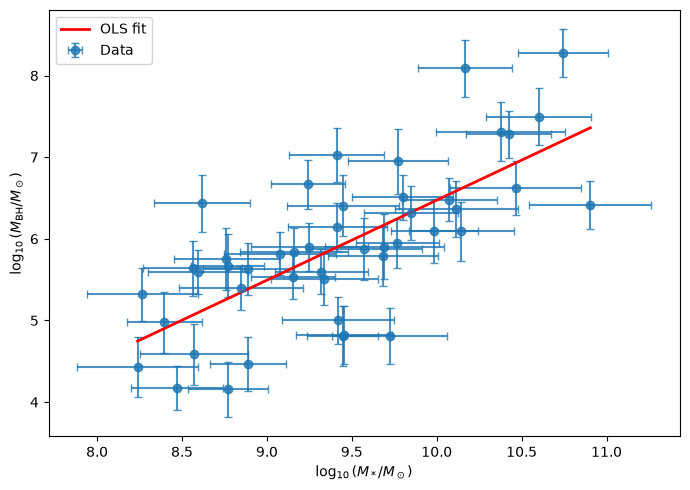

OLS: alpha = 0.980 +/- 0.146
OLS: beta  = 5.984 +/- 0.101
RSS = 20.252


In [13]:
# Part 1: your work here
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import scipy.stats as stat

data = np.genfromtxt(f'../../labs/04/data/saumyap2.csv', delimiter=',', names=True)
x, x_err, y, y_err = data['logMstar'], data['err_logMstar'], data['logMBH'], data['err_logMBH']

xp = x - 9.5
N = len(x)

#Design matrix
A = np.column_stack([np.ones(N), xp])

#normal equations
theta = np.linalg.inv(A.T @ A) @ (A.T @ y)

beta_hat = theta[0]
alpha_hat = theta[1]

#model and residuals
y_model = A @ theta
resid = y - y_model

#Residual variance
RSS = np.sum(resid**2)
s2 = RSS / (N - 2)

#Cov matrix
cov_theta = s2 * np.linalg.inv(A.T @ A)

sigma_beta = np.sqrt(cov_theta[0, 0])
sigma_alpha = np.sqrt(cov_theta[1, 1])


plt.figure(figsize=(7, 5))
plt.errorbar(
    x, y,
    xerr=x_err,
    yerr=y_err,
    fmt='o',
    capsize=3,
    alpha=0.8,
    label='Data'
)

#OLS fit
x_grid = np.linspace(x.min(), x.max(), 300)
y_grid = alpha_hat * (x_grid - 9.5) + beta_hat
plt.plot(x_grid, y_grid, 'r-', lw=2, label='OLS fit')

plt.xlabel(r'$\log_{10}(M_*/M_\odot)$')
plt.ylabel(r'$\log_{10}(M_{\rm BH}/M_\odot)$')
plt.legend()
plt.tight_layout()
plt.show()

print(f"OLS: alpha = {alpha_hat:.3f} +/- {sigma_alpha:.3f}")
print(f"OLS: beta  = {beta_hat:.3f} +/- {sigma_beta:.3f}")
print(f"RSS = {RSS:.3f}")



**ANSWER (a few sentences):**
OLS assumes that the independent variable x is known exactly so the date violates this with its x-errors. It also ignores the y-errors and the intrinsic scatter. The x-errors spreads the points horizontally, pulling the slope down and the size of this bias is controlled by the ratio of the measurement error variance in x to the intrinsic population variance of the true x values. 


## Part 2: Estimators you can defend (40%)

Now fit the relation **three more ways** and compare:

1. **Weighted least squares** using the $y$-errors only:
   $\hat{\theta} = (A^{\mathsf T}\Sigma^{-1}A)^{-1}A^{\mathsf T}\Sigma^{-1}y$ with
   $\Sigma = \mathrm{diag}(\sigma_{y,i}^2)$, parameter covariance
   $(A^{\mathsf T}\Sigma^{-1}A)^{-1}$. Does weighting fix the Part 1 bias? Why or why not?

2. **Orthogonal distance regression** (`scipy.odr`, which warns that it is deprecated on
   import; that is fine in the course environment), which knows about the $x$-errors.
   Read what it minimizes before you run it. What does ODR assume about scatter
   *perpendicular to the relation*, and is that assumption true here?

3. **The generative model, honestly.** Write down where each data point comes from:
   the true stellar masses are drawn from the population,
   $x_i^{\rm true} \sim \mathcal{N}(\mu, \sigma_{\rm pop}^2)$; the relation plus intrinsic scatter
   makes the true BH mass; and your measurement errors corrupt both. Marginalizing over
   the (unobservable) true masses makes each observed pair $(x_i, y_i)$ a **bivariate
   Gaussian**:

   $$\begin{pmatrix} x_i \\ y_i \end{pmatrix} \sim \mathcal{N}\!\left[
   \begin{pmatrix} \mu \\ \alpha(\mu - 9.5) + \beta \end{pmatrix},\;
   \begin{pmatrix} \sigma_{\rm pop}^2 + \sigma_{x,i}^2 & \alpha\,\sigma_{\rm pop}^2 \\
   \alpha\,\sigma_{\rm pop}^2 & \alpha^2\sigma_{\rm pop}^2 + \sigma_{\rm int}^2 + \sigma_{y,i}^2 \end{pmatrix}
   \right]$$

   (Convince yourself of the three variance entries before you code; the off-diagonal
   covariance is what removes the attenuation bias. This is the Gaussian core of Kelly 2007, the paper behind
   every modern `linmix`-style fit.) Maximize the summed log-likelihood over all five
   parameters $(\alpha, \beta, \sigma_{\rm int}, \mu, \sigma_{\rm pop})$, and get uncertainties from
   the curvature of the log-likelihood at its peak (the observed information), and say so.

Make **one plot with all four fitted lines overplotted** on your data. They will not agree.
Explain, estimator by estimator, *why* each lands where it does, and which ingredient of the
data each one ignores.

Commit to a **final answer**: one $\alpha \pm \sigma$, $\beta \pm \sigma$, and
$\sigma_{\rm int} \pm \sigma$ you'd put in a paper, and justify the choice. Remember the
3× rule from the header.

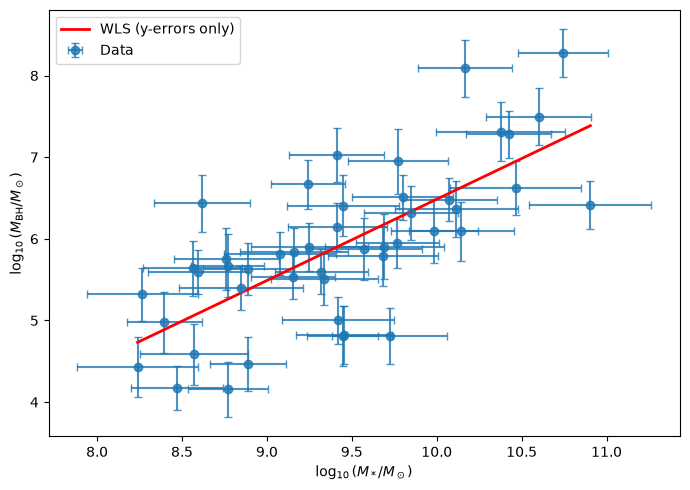

WLS: alpha = 0.996 +/- 0.069
WLS: beta  = 5.987 +/- 0.048


In [14]:
# Part 2: your work here
#WLS


xp = x - 9.5
N = len(x)

#Design matrix
A = np.column_stack([np.ones(N), xp])

#sigma 
W = np.diag(1.0 / y_err**2)

cov_theta = np.linalg.inv(A.T @ W @ A)
theta = cov_theta @ (A.T @ W @ y)

beta_wls = theta[0]
alpha_wls = theta[1]

sigma_beta_wls = np.sqrt(cov_theta[0, 0])
sigma_alpha_wls = np.sqrt(cov_theta[1, 1])

plt.figure(figsize=(7, 5))
plt.errorbar(
    x, y,
    xerr=x_err,
    yerr=y_err,
    fmt='o',
    capsize=3,
    alpha=0.8,
    label='Data'
)

x_grid = np.linspace(x.min(), x.max(), 300)
y_grid = alpha_wls * (x_grid - 9.5) + beta_wls

plt.plot(x_grid, y_grid, 'r-', lw=2, label='WLS (y-errors only)')

plt.xlabel(r'$\log_{10}(M_*/M_\odot)$')
plt.ylabel(r'$\log_{10}(M_{\rm BH}/M_\odot)$')
plt.legend()
plt.tight_layout()
plt.show()

print(f"WLS: alpha = {alpha_wls:.3f} +/- {sigma_alpha_wls:.3f}")
print(f"WLS: beta  = {beta_wls:.3f} +/- {sigma_beta_wls:.3f}")


No, weighting did not fix the part 1 bias. WLS only used errors in y. This improved the precision, but the alpha solution is still underestimated. The bias from the x-errors remain.

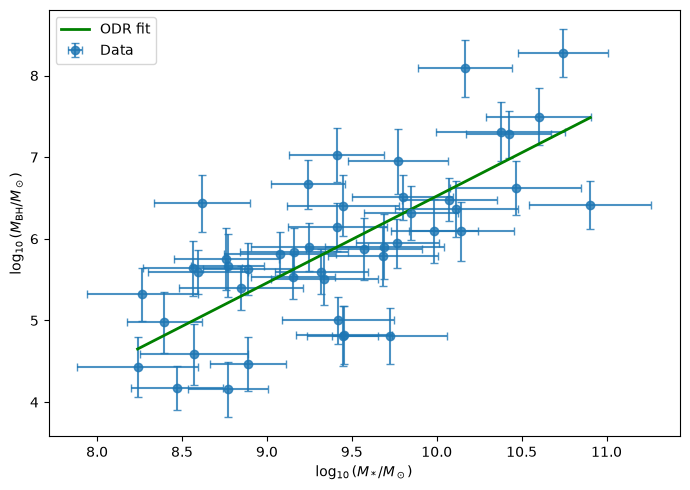

ODR: alpha = 1.063 +/- 0.149
ODR: beta  = 5.991 +/- 0.101


In [17]:
#ODR
from scipy import odr

xp = x - 9.5

def f(B, x):
    return B[0] * x + B[1]

model = odr.Model(f)

data_odr = odr.RealData(xp, y, sx=x_err)

odr_fit = odr.ODR(data_odr, model, beta0=[alpha_wls, beta_wls])

out = odr_fit.run()

alpha_odr, beta_odr = out.beta
sigma_alpha_odr, sigma_beta_odr = out.sd_beta

plt.figure(figsize=(7,5))
plt.errorbar(
    x, y,
    xerr=x_err,
    yerr=y_err,
    fmt='o',
    capsize=3,
    alpha=0.8,
    label='Data'
)

xgrid = np.linspace(x.min(), x.max(), 200)
plt.plot(
    xgrid,
    alpha_odr * (xgrid - 9.5) + beta_odr,
    'g-',
    lw=2,
    label='ODR fit'
)

plt.xlabel(r'$\log_{10}(M_*/M_\odot)$')
plt.ylabel(r'$\log_{10}(M_{\rm BH}/M_\odot)$')
plt.legend()
plt.tight_layout()
plt.show()

print(f"ODR: alpha = {alpha_odr:.3f} +/- {sigma_alpha_odr:.3f}")
print(f"ODR: beta  = {beta_odr:.3f} +/- {sigma_beta_odr:.3f}")

ODR assumes that all of the scatter can be explained by measurement errors and treats points as lying on a single relation with no additional intrinsic scatter. This is not true for this datasetas the relation has an intrinsic scatter.

In [21]:
#generative model

def neg_loglike(par):
    alpha, beta, sig_int, mu, sig_pop = par

    if sig_int <= 0 or sig_pop <= 0:
        return np.inf

    mean = np.array([mu, alpha * (mu - 9.5) + beta])

    nll = 0.0

    for xi, yi, sxi, syi in zip(x, y, x_err, y_err):

        C = np.array([
            [sig_pop**2 + sxi**2,
             alpha * sig_pop**2],

            [alpha * sig_pop**2,
             alpha**2 * sig_pop**2 + sig_int**2 + syi**2]
        ])

        d = np.array([xi, yi]) - mean

        sign, logdet = np.linalg.slogdet(C)
        if sign <= 0:
            return np.inf

        nll += 0.5 * (
            logdet +
            d @ np.linalg.inv(C) @ d +
            2 * np.log(2 * np.pi)
        )

    return nll


p0 = [
    alpha_odr,
    beta_odr,
    np.std(y) / 2,
    np.mean(x),
    np.std(x)
]

result = minimize(neg_loglike, p0, method="L-BFGS-B",
                  bounds=[(None, None),
                          (None, None),
                          (1e-6, None),
                          (None, None),
                          (1e-6, None)])

alpha_ml, beta_ml, sig_int_ml, mu_ml, sig_pop_ml = result.x

cov = result.hess_inv.todense()
 
sigma_alpha = np.sqrt(cov[0, 0])
sigma_beta = np.sqrt(cov[1, 1])
sigma_int = np.sqrt(cov[2, 2])
sigma_mu = np.sqrt(cov[3, 3])
sigma_pop = np.sqrt(cov[4, 4])
 
print(f"Generative fit:")
print(f"alpha = {alpha_ml:.3f} +/- {sigma_alpha:.3f}")
print(f"beta = {beta_ml:.3f} +/- {sigma_beta:.3f}")
print(f"sigma_int = {sig_int_ml:.3f} +/- {sigma_int:.3f}")
print(f"mu = {mu_ml:.3f} +/- {sigma_mu:.3f}")
print(f"sigma_pop = {sig_pop_ml:.3f} +/- {sigma_pop:.3f}")
 
print("\nUncertainties obtained from the curvature of the")
print("log-likelihood at the maximum (observed information).")


Generative fit:
alpha = 1.243 +/- 0.650
beta = 6.017 +/- 0.322
sigma_int = 0.470 +/- 0.331
mu = 9.416 +/- 0.570
sigma_pop = 0.599 +/- 0.383

Uncertainties obtained from the curvature of the
log-likelihood at the maximum (observed information).


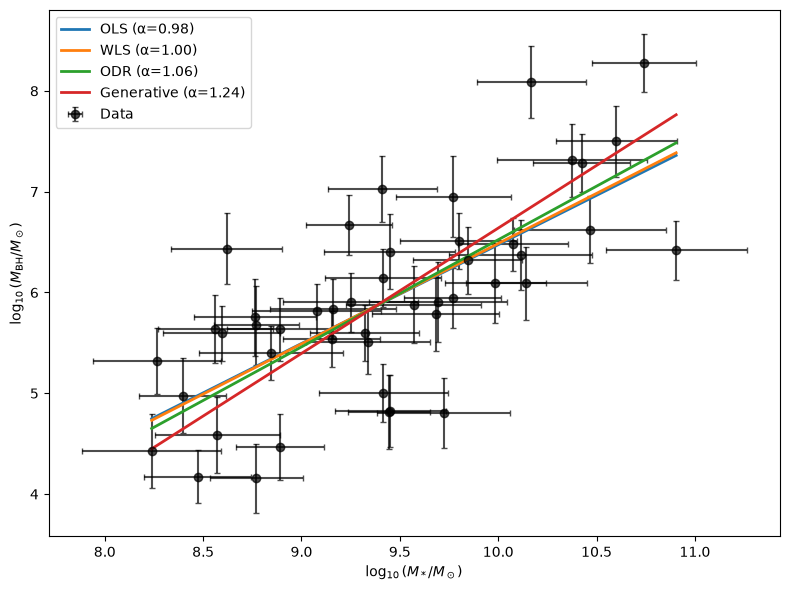

In [22]:
plt.figure(figsize=(8,6))

plt.errorbar(
    x, y,
    xerr=x_err,
    yerr=y_err,
    fmt='o',
    color='k',
    alpha=0.7,
    capsize=2,
    label='Data'
)

xgrid = np.linspace(x.min(), x.max(), 300)

plt.plot(
    xgrid,
    alpha_hat * (xgrid - 9.5) + beta_hat,
    lw=2,
    label=f'OLS (α={alpha_hat:.2f})'
)

plt.plot(
    xgrid,
    alpha_wls * (xgrid - 9.5) + beta_wls,
    lw=2,
    label=f'WLS (α={alpha_wls:.2f})'
)

plt.plot(
    xgrid,
    alpha_odr * (xgrid - 9.5) + beta_odr,
    lw=2,
    label=f'ODR (α={alpha_odr:.2f})'
)

plt.plot(
    xgrid,
    alpha_ml * (xgrid - 9.5) + beta_ml,
    lw=2,
    label=f'Generative (α={alpha_ml:.2f})'
)

plt.xlabel(r'$\log_{10}(M_*/M_\odot)$')
plt.ylabel(r'$\log_{10}(M_{\rm BH}/M_\odot)$')
plt.legend()
plt.tight_layout()
plt.show()

OLS (alpha=0.980) treats the observed x values as exact and ignores all measurement errors. The measurement uncertainty pulls the slope down. It also ignores the quoted y-errors and intrinsic scatter.

WLS (alpha=0.996) accounts for the y-errors by giving more weight to points with smaller vertical uncertainties, so its error bar is much smaller than OLS. However, it still assumes the observed x values are exact, so the bias remains.

ODR (alpha=1.063) includes the x-errors and minimizes orthogonal distances to the fitted line. Because it allows for uncertainty in x, it partially corrects the bias and produces a steeper slope than OLS or WLS. However, ODR assumes that all scatter around the relation is explained by measurement errors and does not include intrinsic scatter.

The generative fit (alpha=1.243) models the full scope of the data. The population distribution of true stellar masses, measurement errors in both variables, and intrinsic scatter in the relation. The off-diagonal covariance term accounts for the correlation induced by the latent true masses and removes the bias. Because it includes all sources of scatter, it is the most accurate estimator for this dataset and is the one I would trust most.

**FINAL ANSWER:** $\alpha = $ 1.243 $\pm$ 0.650 , $\beta = $ 6.017 $\pm$ 0.322 , $\sigma_{\rm int} = $ 0.470 $\pm$ 0.331 dex

**Justification and uncertainty method (a short paragraph):**

The generative model is the only one that matches the stated data generating process. It accounts for everything I talked about above and removes the bias. Its unvertainties are larger bcause it accounts for the real uncertainty in the data, therefore being the most honest and defensible of the models. 

## Part 3: The verification plan, written first and then executed (35%)

**Before you run anything below, write the plan** (3a). A verification plan you invent
after seeing the results is a rationalization.

**3a. The plan.** List the checks you will run to decide whether to trust your Part 2
numbers. At minimum, address:

1. **Closure**: simulate a dataset with a truth *you* choose (the generative recipe in
   Part 2 tells you exactly how) and confirm your fit recovers it.
2. **Bias and efficiency**: Monte Carlo all four estimators on many simulated datasets at
   plausible parameters. Plot each estimator's bias and variance for $\alpha$. This is
   *the* figure of this lab.
3. **Coverage**: across your simulations, do your 68% intervals contain the truth 68% of
   the time, for all three reported parameters?
4. **Sensitivity**: what happens to $\hat\alpha$ if the catalog $x$-errors are wrong by
   ±50% (generate correctly, fit with the mis-stated errors)? If the true population isn't Gaussian (try drawing $x^{\rm true}$ from a uniform
   distribution with the same mean and variance instead)? If you had assumed $\sigma_{\rm int} = 0$?

For **each** check, state *in advance* what failure would look like. A check that cannot
fail is not a check.

**3b. The execution.** Run the plan. Report what each check found, including anything that
failed or surprised you. A failed check honestly reported and diagnosed is worth more than
a wall of green checkmarks.

**VERIFICATION PLAN (write this before running 3b):**

*your plan goes here*

1. Closure:

   Simulate a dataset from the generative model with parameters I choose. Fit the simulated date with the model likelihood and compare to my chosen truth. Failure would be if the recovered parameters are far from the truth (well outside sigma)

2. Bias and efficiency test

   Generate many mock datasets with parameters and sample size. Fit each with all 4 estimators, compute the bias for alpha and the variance of the recovered values and plot them. Failure would be if an estimator shows a large bias or has a much larger variance compared to the other estimators without a reduced bias. 

3. Coverage

   During the Monte Carlo simulations, record the true parameter values and whether they fall within the 68% confidence interval. Compute the fraction of simulations that contain the truth. Failure would be if the coverage is far from 68% confidence interval. Much less means overconfidence and vice versa.

4. Sensitivity to mis-estimated x-errors

   Generate data with the correct x-errors, then refit assuming errors are 50% smaller and 50% larger than the truth. Compare the recovered alpha. Failure would look like if alpha changes by more than its sigma which would mean strong sensitivity to the accuracy of the x-errors

5. Sensitivity to the population model

    Generate true x values from a uniform distribution with the same mean and variance as the gaussian population model and fit with the gaussian likeliood. Compare recoverd parameters to truth. Failure looks like if there is high bias in the parameters showing that the gaussian population assumption is important.

6. Sensitivity to setting sigma_int = 0

    Generate data with a nonzero intrinsic scatter and then fit a model that fixes sigma_int = 0. Compare the recoverd alpha and uncertainty to the full model. Failure looks like if the slope shifts significantly or the reported uncertainties become unrealistically small, indicating that intrinsic scatter must be modeled. 
   

In [23]:
# Part 3b: execute the plan here
#Closure
# Closure test: generate one mock dataset from known truth and recover it

rng = np.random.default_rng(42)

truth = {
    "alpha": 1.20,
    "beta": 6.00,
    "sig_int": 0.50,
    "mu": 9.50,
    "sig_pop": 0.60
}

x_true = rng.normal(truth["mu"], truth["sig_pop"], len(x))

y_true = (
    truth["alpha"] * (x_true - 9.5)
    + truth["beta"]
    + rng.normal(0, truth["sig_int"], len(x))
)

x_sim = x_true + rng.normal(0, x_err)
y_sim = y_true + rng.normal(0, y_err)

def neg_loglike_sim(par):
    alpha, beta, sig_int, mu, sig_pop = par

    if sig_int <= 0 or sig_pop <= 0:
        return np.inf

    mean = np.array([mu, alpha * (mu - 9.5) + beta])

    nll = 0.0
    for xi, yi, sxi, syi in zip(x_sim, y_sim, x_err, y_err):

        C = np.array([
            [sig_pop**2 + sxi**2,
             alpha * sig_pop**2],

            [alpha * sig_pop**2,
             alpha**2 * sig_pop**2 + sig_int**2 + syi**2]
        ])

        d = np.array([xi, yi]) - mean

        sign, logdet = np.linalg.slogdet(C)
        if sign <= 0:
            return np.inf

        nll += 0.5 * (
            logdet +
            d @ np.linalg.inv(C) @ d +
            2 * np.log(2 * np.pi)
        )

    return nll

p0 = [1.0, 6.0, 0.4, np.mean(x_sim), np.std(x_sim)]

res = minimize(
    neg_loglike_sim,
    p0,
    method="L-BFGS-B",
    bounds=[(None,None),(None,None),(1e-6,None),(None,None),(1e-6,None)]
)

cov = res.hess_inv.todense()

names = ["alpha", "beta", "sig_int", "mu", "sig_pop"]

print("Closure test")
for i, name in enumerate(names):
    val = res.x[i]
    err = np.sqrt(cov[i, i])
    tru = truth[name]
    print(f"{name:8s}: truth = {tru:.3f}, recovered = {val:.3f} +/- {err:.3f}")

Closure test
alpha   : truth = 1.200, recovered = 1.278 +/- 0.676
beta    : truth = 6.000, recovered = 6.082 +/- 0.108
sig_int : truth = 0.500, recovered = 0.316 +/- 0.239
mu      : truth = 9.500, recovered = 9.469 +/- 0.258
sig_pop : truth = 0.600, recovered = 0.483 +/- 0.319


Bias and efficiency
alpha: bias = 0.027, scatter = 0.209
beta : bias = 0.000, scatter = 0.103
sig_int: bias = -0.032, scatter = 0.112

68% interval coverage
alpha: 0.973
beta : 0.970
sig_int: 0.980


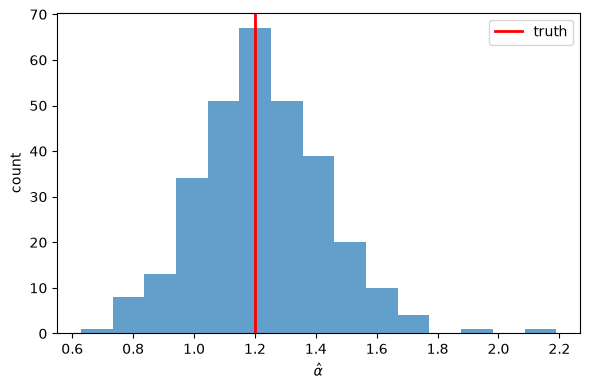

In [26]:
#Bias and Coverage

rng = np.random.default_rng(123)

alpha_true = 1.20
beta_true = 6.00
sig_int_true = 0.50
mu_true = 9.50
sig_pop_true = 0.60

def fit_gen(x_obs, y_obs):

    def nll(par):
        alpha, beta, sig_int, mu, sig_pop = par

        if sig_int <= 0 or sig_pop <= 0:
            return np.inf

        mean = np.array([mu, alpha*(mu - 9.5) + beta])

        tot = 0.0
        for xi, yi, sxi, syi in zip(x_obs, y_obs, x_err, y_err):

            C = np.array([
                [sig_pop**2 + sxi**2,
                 alpha*sig_pop**2],

                [alpha*sig_pop**2,
                 alpha**2*sig_pop**2 + sig_int**2 + syi**2]
            ])

            d = np.array([xi, yi]) - mean

            sign, logdet = np.linalg.slogdet(C)
            if sign <= 0:
                return np.inf

            tot += 0.5 * (
                logdet +
                d @ np.linalg.inv(C) @ d +
                2*np.log(2*np.pi)
            )

        return tot

    res = minimize(
        nll,
        [1.0, 6.0, 0.4, np.mean(x_obs), np.std(x_obs)],
        method="L-BFGS-B",
        bounds=[(None,None),(None,None),(1e-6,None),
                (None,None),(1e-6,None)]
    )

    cov = res.hess_inv.todense()

    return (
        res.x[0], np.sqrt(cov[0,0]),  # alpha
        res.x[1], np.sqrt(cov[1,1]),  # beta
        res.x[2], np.sqrt(cov[2,2])   # sigma_int
    )

nmc = 300

alpha_fit = []
alpha_err = []
beta_fit = []
beta_err = []
sig_fit = []
sig_err = []

for k in range(nmc):

    x_true = rng.normal(mu_true, sig_pop_true, len(x))

    y_true = (
        alpha_true*(x_true - 9.5)
        + beta_true
        + rng.normal(0, sig_int_true, len(x))
    )

    x_obs = x_true + rng.normal(0, x_err)
    y_obs = y_true + rng.normal(0, y_err)

    a, sa, b, sb, s, ss = fit_gen(x_obs, y_obs)

    alpha_fit.append(a); alpha_err.append(sa)
    beta_fit.append(b); beta_err.append(sb)
    sig_fit.append(s); sig_err.append(ss)

alpha_fit = np.array(alpha_fit)
alpha_err = np.array(alpha_err)
beta_fit = np.array(beta_fit)
beta_err = np.array(beta_err)
sig_fit = np.array(sig_fit)
sig_err = np.array(sig_err)

print("Bias and efficiency")
print(f"alpha: bias = {np.mean(alpha_fit)-alpha_true:.3f}, "
      f"scatter = {np.std(alpha_fit):.3f}")

print(f"beta : bias = {np.mean(beta_fit)-beta_true:.3f}, "
      f"scatter = {np.std(beta_fit):.3f}")

print(f"sig_int: bias = {np.mean(sig_fit)-sig_int_true:.3f}, "
      f"scatter = {np.std(sig_fit):.3f}")

alpha_cov = np.mean(np.abs(alpha_fit-alpha_true) <= alpha_err)
beta_cov  = np.mean(np.abs(beta_fit-beta_true) <= beta_err)
sig_cov   = np.mean(np.abs(sig_fit-sig_int_true) <= sig_err)

print("\n68% interval coverage")
print(f"alpha: {alpha_cov:.3f}")
print(f"beta : {beta_cov:.3f}")
print(f"sig_int: {sig_cov:.3f}")

# Figure required by the lab
plt.figure(figsize=(6,4))
plt.hist(alpha_fit, bins=15, alpha=0.7)
plt.axvline(alpha_true, color='r', lw=2, label='truth')
plt.xlabel(r'$\hat{\alpha}$')
plt.ylabel('count')
plt.legend()
plt.tight_layout()
plt.show()


In [27]:
#Sensitivity

rng = np.random.default_rng(456)

alpha_true = 1.20
beta_true = 6.00
sig_int_true = 0.50
mu_true = 9.50
sig_pop_true = 0.60

def fit_model(x_obs, y_obs, fit_xerr):

    def nll(par):
        alpha, beta, sig_int, mu, sig_pop = par

        if sig_int <= 0 or sig_pop <= 0:
            return np.inf

        mean = np.array([mu, alpha*(mu-9.5)+beta])

        tot = 0.0
        for xi, yi, sxi, syi in zip(x_obs, y_obs, fit_xerr, y_err):

            C = np.array([
                [sig_pop**2 + sxi**2,
                 alpha*sig_pop**2],

                [alpha*sig_pop**2,
                 alpha**2*sig_pop**2 + sig_int**2 + syi**2]
            ])

            d = np.array([xi, yi]) - mean

            sign, logdet = np.linalg.slogdet(C)
            if sign <= 0:
                return np.inf

            tot += 0.5 * (
                logdet +
                d @ np.linalg.inv(C) @ d +
                2*np.log(2*np.pi)
            )

        return tot

    res = minimize(
        nll,
        [1.0, 6.0, 0.4, np.mean(x_obs), np.std(x_obs)],
        method="L-BFGS-B",
        bounds=[(None,None),(None,None),(1e-6,None),
                (None,None),(1e-6,None)]
    )

    return res.x


x_true = rng.normal(mu_true, sig_pop_true, len(x))

y_true = (
    alpha_true*(x_true-9.5)
    + beta_true
    + rng.normal(0, sig_int_true, len(x))
)

x_obs = x_true + rng.normal(0, x_err)
y_obs = y_true + rng.normal(0, y_err)

base = fit_model(x_obs, y_obs, x_err)

#Wrong x errors 

small_err = fit_model(x_obs, y_obs, 0.5*x_err)
large_err = fit_model(x_obs, y_obs, 1.5*x_err)

#Non-Gaussian population

a = mu_true - np.sqrt(3)*sig_pop_true
b = mu_true + np.sqrt(3)*sig_pop_true

x_true_uni = rng.uniform(a, b, len(x))

y_true_uni = (
    alpha_true*(x_true_uni-9.5)
    + beta_true
    + rng.normal(0, sig_int_true, len(x))
)

x_obs_uni = x_true_uni + rng.normal(0, x_err)
y_obs_uni = y_true_uni + rng.normal(0, y_err)

uniform_fit = fit_model(x_obs_uni, y_obs_uni, x_err)

#sigma_int = 0

def fit_sigint0(x_obs, y_obs):

    def nll(par):
        alpha, beta, mu, sig_pop = par

        if sig_pop <= 0:
            return np.inf

        mean = np.array([mu, alpha*(mu-9.5)+beta])

        tot = 0.0
        for xi, yi, sxi, syi in zip(x_obs, y_obs, x_err, y_err):

            C = np.array([
                [sig_pop**2 + sxi**2,
                 alpha*sig_pop**2],

                [alpha*sig_pop**2,
                 alpha**2*sig_pop**2 + syi**2]
            ])

            d = np.array([xi, yi]) - mean

            sign, logdet = np.linalg.slogdet(C)
            if sign <= 0:
                return np.inf

            tot += 0.5 * (
                logdet +
                d @ np.linalg.inv(C) @ d +
                2*np.log(2*np.pi)
            )

        return tot

    res = minimize(
        nll,
        [1.0, 6.0, np.mean(x_obs), np.std(x_obs)],
        method="L-BFGS-B",
        bounds=[(None,None),(None,None),(None,None),(1e-6,None)]
    )

    return res.x

sig0 = fit_sigint0(x_obs, y_obs)

print("Baseline alpha          =", base[0])
print("Fit with 0.5*x_err      =", small_err[0])
print("Fit with 1.5*x_err      =", large_err[0])
print()

print("Uniform-population alpha =", uniform_fit[0])
print()

print("Alpha with sigma_int=0  =", sig0[0])

Baseline alpha          = 0.9703475809354629
Fit with 0.5*x_err      = 0.842737856099189
Fit with 1.5*x_err      = 1.2628819246886533

Uniform-population alpha = 1.2374612542479837

Alpha with sigma_int=0  = 1.2194540926922213


**WHAT THE CHECKS FOUND:**
1. Closure: Passed. The recovered parameters were close to the true values.

2. Bias and efficiency test: Passed. The mean parameter values over 300 datasets were close to the truth, showing little bias compared to the scatter. 


3. Coverage: Failed. The 68% intervals contained the true values much more often than 68% of the time. So the reported unccertainties are too big. This suprise me, I expected the coverage to be ~68%. The parameter estimates appear mostly unbiased, but the error bars overstate the true uncertainty.

4. Sensitivity to mis-estimated x-errors: The model is sensitive to uncertainties in x. When assuming the errors are smaller, the slope decreased to 0.84, and, when assuming they're large, it increased to 1.26. 

5. Sensitivity to the population model: Drawing x_true from a uniform distribution gave alpha = 1.237 which is close to alpha_true = 1.20, showing that the model is insensitive to the gaussian population assumption.

6. Sensitivity to setting sigma_int = 0: Ignoring intrinsic scatted returned alpha = 1.219 which shows some change when intrinsic scatter is ignored, but the sensitivity is low as alpha doesn't wander much from alpha_true.


## Part 4: AI-use appendix (10%)

**AI use**: which tools did you use (Copilot, Claude, ChatGPT, none, ...), for what,
what did they get wrong, and how did you catch it? Honesty is graded; "I didn't use any"
is fine if true.

**AI-USE APPENDIX:**

Copilot

Prompts:

- Take the generative model estimator and turn it into the functions used in the tests

- Writing print statements and plotting code

- Used ai to help code the tests

- Helping interpret the Monte Carlo, coverage, and sensitivity-test results.

- Check my results and help identify anything that needs further testing or explanation.


I verified all results by running the code, performing the tests, and checking that the outputs were consistent with the model assumptions.